In [12]:
from unet1 import UNet
from testing_model import LightningModel
from helper_functions import *
from testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
import csv
import string
ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
import warnings
hparams = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "nb_levels": 4,
    "nb_inner_channels": 32,
    "nb_conv_layers_per_stage": 2,
    "data_slice_only": True,
    "max_epochs": 250,
}
mice = ['../Datasets/optoacousticsparse/mice_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/mice_full_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse64_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse128_recon_256.mat']
v_phantom = ['../Datasets/optoacousticsparse/v_phantom_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_full_recon_256.mat']


In [13]:
# Generalized
path_PAOmniNet_alpha_generalized = 'weights/PAOmni/OADAT/Alpha/PA_OmniNet_Generalized.ckpt'
path_PAOmniNet_ssim_generalized = 'weights/PAOmni/OADAT/SSIM/PA_OmniNet_Generalized.ckpt'
path_PAOmniNet_mse_generalized = 'weights/PAOmni/OADAT/MSE/PA_OmniNet_Generalized.pth'

path_Unet_alpha_generalized = 'weights/Unet/OADAT/Alpha/Unet_Generalized.pth'
path_Unet_ssim_generalized = 'weights/Unet/OADAT/SSIM/Unet_Generalized.pth'
path_Unet_mse_generalized =  'weights/Unet/OADAT/MSE/Unet_Generalized.pth'

# Mouse 16
path_PAOmniNet_alpha_mouse16 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_mouse16.ckpt'
path_PAOmniNet_ssim_mouse16 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_mouse16.ckpt'
path_PAOmniNet_mse_mouse16 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_mouse16.pth'

path_Unet_alpha_mouse16 = 'weights/Unet/Mice/Alpha/Unet_mouse16.pth'
path_Unet_ssim_mouse16 = 'weights/Unet/Mice/SSIM/Unet_mouse16.pth'
path_Unet_mse_mouse16 = 'weights/Unet/Mice/MSE/Unet_mouse16.pth'

# Mouse 32
path_PAOmniNet_alpha_mouse32 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_mouse32.ckpt'
path_PAOmniNet_ssim_mouse32 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_mouse32.ckpt'
path_PAOmniNet_mse_mouse32 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_mouse32.pth'

path_Unet_alpha_mouse32 = 'weights/Unet/Mice/Alpha/Unet_mouse32.pth'
path_Unet_ssim_mouse32 = 'weights/Unet/Mice/SSIM/Unet_mouse32.pth'
path_Unet_mse_mouse32 = 'weights/Unet/Mice/MSE/Unet_mouse32.pth'

# Mouse 64
path_PAOmniNet_alpha_mouse64 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_mouse64.ckpt'
path_PAOmniNet_ssim_mouse64 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_mouse64.ckpt'
path_PAOmniNet_mse_mouse64 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_mouse64.ckpt'

path_Unet_alpha_mouse64 = 'weights/Unet/Mice/Alpha/Unet_mouse64.pth'
path_Unet_ssim_mouse64 = 'weights/Unet/Mice/SSIM/Unet_mouse64.pth'
path_Unet_mse_mouse64 = 'weights/Unet/Mice/MSE/Unet_mouse64.pth'

# Mouse 128
path_PAOmniNet_alpha_mouse128 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_mouse128.ckpt'
path_PAOmniNet_ssim_mouse128 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_mouse128.ckpt'
path_PAOmniNet_mse_mouse128 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_mouse128.ckpt'

path_Unet_alpha_mouse128 = 'weights/Unet/Mice/Alpha/Unet_mouse128.pth'
path_Unet_ssim_mouse128 = 'weights/Unet/Mice/SSIM/Unet_mouse128.pth'
path_Unet_mse_mouse128 = 'weights/Unet/Mice/MSE/Unet_mouse128.pth'

# Vphantom 16
path_PAOmniNet_alpha_vphantom16 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_vphantom16.ckpt'
path_PAOmniNet_ssim_vphantom16 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_vphantom16.ckpt'
path_PAOmniNet_mse_vphantom16 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_vphantom16.pth'

path_Unet_alpha_vphantom16 = 'weights/Unet/Mice/Alpha/Unet_vphantom16.pth'
path_Unet_ssim_vphantom16 = 'weights/Unet/Mice/SSIM/Unet_vphantom16.pth'
path_Unet_mse_vphantom16 = 'weights/Unet/Mice/MSE/Unet_vphantom16.pth'

# Vphantom 32
path_PAOmniNet_alpha_vphantom32 = 'weights/PAOmni/Mice/Alpha/PA_OmniNet_vphantom32.ckpt'
path_PAOmniNet_ssim_vphantom32 = 'weights/PAOmni/Mice/SSIM/PA_OmniNet_vphantom32.ckpt'
path_PAOmniNet_mse_vphantom32 = 'weights/PAOmni/Mice/MSE/PA_OmniNet_vphantom32.pth'

path_Unet_alpha_vphantom32 = 'weights/Unet/Mice/Alpha/Unet_vphantom32.pth'
path_Unet_ssim_vphantom32 = 'weights/Unet/Mice/SSIM/Unet_vphantom32.pth'
path_Unet_mse_vphantom32 = 'weights/Unet/Mice/MSE/Unet_vphantom32.pth'

In [14]:
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore")
# Generalized
# PAOmniNet models
PAOmniNet_alpha_generalized = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_generalized, map_location=torch.device('cpu'))
PAOmniNet_ssim_generalized = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_generalized, map_location=torch.device('cpu'))

PAOmniNet_mse_generalized = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_generalized, map_location=torch.device('cpu'))
PAOmniNet_mse_generalized.load_state_dict(state_dict)

# Unet models
Unet_alpha_generalized = UNet()
Unet_alpha_generalized.load_state_dict(torch.load(path_Unet_alpha_generalized, map_location=torch.device('cpu')))
Unet_alpha_generalized.eval()

Unet_ssim_generalized = UNet()
Unet_ssim_generalized.load_state_dict(torch.load(path_Unet_ssim_generalized, map_location=torch.device('cpu')))
Unet_ssim_generalized.eval()

Unet_mse_generalized = UNet()
Unet_mse_generalized.load_state_dict(torch.load(path_Unet_mse_generalized, map_location=torch.device('cpu')))
Unet_mse_generalized.eval()

# Mouse 16
# PAOmniNet models
PAOmniNet_alpha_mouse16 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_mouse16, map_location=torch.device('cpu'))
PAOmniNet_ssim_mouse16 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_mouse16, map_location=torch.device('cpu'))

PAOmniNet_mse_mouse16 = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_mouse16, map_location=torch.device('cpu'))
PAOmniNet_mse_mouse16.load_state_dict(state_dict)

# Unet models
Unet_alpha_mouse16 = UNet()
Unet_alpha_mouse16.load_state_dict(torch.load(path_Unet_alpha_mouse16, map_location=torch.device('cpu')))
Unet_alpha_mouse16.eval()

Unet_ssim_mouse16 = UNet()
Unet_ssim_mouse16.load_state_dict(torch.load(path_Unet_ssim_mouse16, map_location=torch.device('cpu')))
Unet_ssim_mouse16.eval()

Unet_mse_mouse16 = UNet()
Unet_mse_mouse16.load_state_dict(torch.load(path_Unet_mse_mouse16, map_location=torch.device('cpu')))
Unet_mse_mouse16.eval()

# Mouse 32
# PAOmniNet models
PAOmniNet_alpha_mouse32 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_mouse32, map_location=torch.device('cpu'))
PAOmniNet_ssim_mouse32 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_mouse32, map_location=torch.device('cpu'))

PAOmniNet_mse_mouse32 = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_mouse32, map_location=torch.device('cpu'))
PAOmniNet_mse_mouse32.load_state_dict(state_dict)

# Unet models
Unet_alpha_mouse32 = UNet()
Unet_alpha_mouse32.load_state_dict(torch.load(path_Unet_alpha_mouse32, map_location=torch.device('cpu')))
Unet_alpha_mouse32.eval()

Unet_ssim_mouse32 = UNet()
Unet_ssim_mouse32.load_state_dict(torch.load(path_Unet_ssim_mouse32, map_location=torch.device('cpu')))
Unet_ssim_mouse32.eval()

Unet_mse_mouse32 = UNet()
Unet_mse_mouse32.load_state_dict(torch.load(path_Unet_mse_mouse32, map_location=torch.device('cpu')))
Unet_mse_mouse32.eval()

# Mouse 64
# PAOmniNet models
PAOmniNet_alpha_mouse64 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_mouse64, map_location=torch.device('cpu'))
PAOmniNet_ssim_mouse64 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_mouse64, map_location=torch.device('cpu'))
PAOmniNet_mse_mouse64 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_mse_mouse64, map_location=torch.device('cpu'))

# Unet models
Unet_alpha_mouse64 = UNet()
Unet_alpha_mouse64.load_state_dict(torch.load(path_Unet_alpha_mouse64, map_location=torch.device('cpu')))
Unet_alpha_mouse64.eval()

Unet_ssim_mouse64 = UNet()
Unet_ssim_mouse64.load_state_dict(torch.load(path_Unet_ssim_mouse64, map_location=torch.device('cpu')))
Unet_ssim_mouse64.eval()

Unet_mse_mouse64 = UNet()
Unet_mse_mouse64.load_state_dict(torch.load(path_Unet_mse_mouse64, map_location=torch.device('cpu')))
Unet_mse_mouse64.eval()

# Mouse 128
# PAOmniNet models
PAOmniNet_alpha_mouse128 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_mouse128, map_location=torch.device('cpu'))
PAOmniNet_ssim_mouse128 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_mouse128, map_location=torch.device('cpu'))
PAOmniNet_mse_mouse128 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_mse_mouse128, map_location=torch.device('cpu'))

# Unet models
Unet_alpha_mouse128 = UNet()
Unet_alpha_mouse128.load_state_dict(torch.load(path_Unet_alpha_mouse128, map_location=torch.device('cpu')))
Unet_alpha_mouse128.eval()

Unet_ssim_mouse128 = UNet()
Unet_ssim_mouse128.load_state_dict(torch.load(path_Unet_ssim_mouse128, map_location=torch.device('cpu')))
Unet_ssim_mouse128.eval()

Unet_mse_mouse128 = UNet()
Unet_mse_mouse128.load_state_dict(torch.load(path_Unet_mse_mouse128, map_location=torch.device('cpu')))
Unet_mse_mouse128.eval()

# Vphantom 16
# PAOmniNet models
PAOmniNet_alpha_vphantom16 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_vphantom16, map_location=torch.device('cpu'))
PAOmniNet_ssim_vphantom16 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_vphantom16, map_location=torch.device('cpu'))

PAOmniNet_mse_vphantom16 = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_vphantom16, map_location=torch.device('cpu'))
PAOmniNet_mse_vphantom16.load_state_dict(state_dict)

# Unet models
Unet_alpha_vphantom16 = UNet()
Unet_alpha_vphantom16.load_state_dict(torch.load(path_Unet_alpha_vphantom16, map_location=torch.device('cpu')))
Unet_alpha_vphantom16.eval()

Unet_ssim_vphantom16 = UNet()
Unet_ssim_vphantom16.load_state_dict(torch.load(path_Unet_ssim_vphantom16, map_location=torch.device('cpu')))
Unet_ssim_vphantom16.eval()

Unet_mse_vphantom16 = UNet()
Unet_mse_vphantom16.load_state_dict(torch.load(path_Unet_mse_vphantom16, map_location=torch.device('cpu')))
Unet_mse_vphantom16.eval()

# Vphantom 32
# PAOmniNet models
PAOmniNet_alpha_vphantom32 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_alpha_vphantom32, map_location=torch.device('cpu'))
PAOmniNet_ssim_vphantom32 = LightningModel.load_from_checkpoint(checkpoint_path=path_PAOmniNet_ssim_vphantom32, map_location=torch.device('cpu'))

PAOmniNet_mse_vphantom32 = LightningModel(hparams)
state_dict = torch.load(path_PAOmniNet_mse_vphantom32, map_location=torch.device('cpu'))
PAOmniNet_mse_vphantom32.load_state_dict(state_dict)

# Unet models
Unet_alpha_vphantom32 = UNet()
Unet_alpha_vphantom32.load_state_dict(torch.load(path_Unet_alpha_vphantom32, map_location=torch.device('cpu')))
Unet_alpha_vphantom32.eval()

Unet_ssim_vphantom32 = UNet()
Unet_ssim_vphantom32.load_state_dict(torch.load(path_Unet_ssim_vphantom32, map_location=torch.device('cpu')))
Unet_ssim_vphantom32.eval()

Unet_mse_vphantom32 = UNet()
Unet_mse_vphantom32.load_state_dict(torch.load(path_Unet_mse_vphantom32, map_location=torch.device('cpu')))
Unet_mse_vphantom32.eval()

print('All models are loaded!')

All models are loaded!


In [15]:
def preprocess_Unet(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    return image

def preprocess_batch_Unet(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_Unet(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

def data_loader_formatter(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

def preprocess_mat_Neuralizer(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    image = np.stack([image] * 3, axis=-1)
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    image = image.permute(0, 3, 1, 2).float()
    return image


def data_loader_formatter_Neuralizer(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

def preprocess_batch_Neuralizer(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_mat_Neuralizer(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

In [16]:
def get_all_test_data(dataset:str, indices:list, CONTEXT_SIZE=4):
    data_in = dataset[indices[0]]
    data_out = dataset[indices[1]]

    X, y = data_loader_formatter_Neuralizer(data_in,data_out)
    size = X.shape[0]

    indices = np.arange(size)
    train_end = int(0.7 * size)
    val_end = train_end + int(0.2 * size)

    train_indices = indices[:train_end]
    test_indices = indices[val_end:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]



    X_train_Neur = preprocess_batch_Neuralizer(X_train)
    y_train_Neur = preprocess_batch_Neuralizer(y_train)
    X_train_Unet = preprocess_batch_Unet(X_train)
    y_train_Unet = preprocess_batch_Unet(y_train)


    X_test_Unet = preprocess_batch_Unet(X_test)
    y_test_Unet = preprocess_batch_Unet(y_test)
    X_context = X_train_Neur[:CONTEXT_SIZE]
    y_context = y_train_Neur[:CONTEXT_SIZE]

    X_test_Neur = preprocess_batch_Neuralizer(X_test)
    y_test_Neur = preprocess_batch_Neuralizer(y_test)

    print(f'In this order:\nX_test_Neur = {X_test_Neur.shape}, y_test_Neur = {y_test_Neur.shape}, X_context = {X_context.shape}, y_context = {y_context.shape}\n'
          f'X_test_Unet = {X_test_Unet.shape}, y_test_Unet = {y_test_Unet.shape}')
    return X_test_Neur[0], y_test_Neur[0], X_context, y_context, X_test_Unet, y_test_Unet

In [17]:
def get_row(X_Neuralizer, y_Neuralizer, context_in, context_out, X_Unet, y_Unet, Neur_Generalized, Unet_Generalized, Neur_specific, Unet_specific):
    input_Unet = X_Unet
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_Neuralizer.unsqueeze(0)

    ground_truth_Unet = y_Unet
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_Neuralizer.unsqueeze(0)

    output_Neur_Semi = Neur_Generalized.forward(input_Neur, context_in, context_out)
    output_Neur_Semi =(output_Neur_Semi - output_Neur_Semi.min()) / (output_Neur_Semi.max() - output_Neur_Semi.min())

    output_Neur_specific = Neur_specific.forward(input_Neur, context_in, context_out)
    output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())

    output_Unet_Semi = Unet_Generalized(input_Unet.squeeze(0))
    output_Unet_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())

    output_Unet_specific = Unet_specific(input_Unet.squeeze(0))
    output_Unet_specific = (output_Unet_specific - output_Unet_specific.min()) / (output_Unet_specific.max() - output_Unet_specific.min())

    rmse_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_base = ssim(ground_truth_Neur.squeeze(1), input_Neur.squeeze(1)).item()
    baseline_metrics = [rmse_base, psnr_base, ssim_base]

    rmse_neur_semi = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    psnr_neur_semi = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_Semi.squeeze(0))
    ssim_neur_semi = ssim(ground_truth_Neur.squeeze(1), output_Neur_Semi).item()
    PA_generalized_metrics = [rmse_neur_semi, psnr_neur_semi, ssim_neur_semi]

    rmse_neur_specific = compute_rmse(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    psnr_neur_specific = compute_psnr(ground_truth_Neur.squeeze(0), output_Neur_specific.squeeze(0))
    ssim_neur_specific = ssim(ground_truth_Neur.squeeze(1), output_Neur_specific).item()
    PA_specific_metrics = [rmse_neur_specific, psnr_neur_specific, ssim_neur_specific]

    rmse_unet_semi = compute_rmse(ground_truth_Unet, output_Unet_Semi)
    psnr_unet_semi = compute_psnr(ground_truth_Unet, output_Unet_Semi)
    ssim_unet_semi = ssim(ground_truth_Unet.squeeze(1), output_Unet_Semi).item()
    Unet_generalized_metrics = [rmse_unet_semi, psnr_unet_semi, ssim_unet_semi]

    rmse_unet_specific = compute_rmse(ground_truth_Unet, output_Unet_specific)
    psnr_unet_specific = compute_psnr(ground_truth_Unet, output_Unet_specific)
    ssim_unet_specific = ssim(ground_truth_Unet.squeeze(1), output_Unet_specific).item()
    Unet_specific_metrics = [rmse_unet_specific, psnr_unet_specific, ssim_unet_specific]

    input_img = input_Unet.squeeze().cpu().detach().numpy()
    PA_generalized_img = output_Neur_Semi.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    PA_specific_img = output_Neur_specific.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    Unet_generalized_img = output_Unet_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    Unet_specific_img = output_Unet_specific.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    output_img = ground_truth_Unet.squeeze().cpu().detach().numpy()
    return input_img, Unet_generalized_img, Unet_specific_img, PA_generalized_img, PA_specific_img, output_img, [baseline_metrics, Unet_generalized_metrics, Unet_specific_metrics, PA_generalized_metrics, PA_specific_metrics]

In [25]:
def get_all_test_data(dataset:str, indices:list, CONTEXT_SIZE=4):
    data_in = dataset[indices[0]]
    data_out = dataset[indices[1]]

    X, y = data_loader_formatter_Neuralizer(data_in,data_out)
    size = X.shape[0]

    indices = np.arange(size)
    train_end = int(0.6 * size)
    val_end = train_end + int(0.2 * size)

    train_indices = indices[:train_end]
    test_indices = indices[val_end+1:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]



    X_train_Neur = preprocess_batch_Neuralizer(X_train)
    y_train_Neur = preprocess_batch_Neuralizer(y_train)
    X_train_Unet = preprocess_batch_Unet(X_train)
    y_train_Unet = preprocess_batch_Unet(y_train)


    X_test_Unet = preprocess_batch_Unet(X_test)
    y_test_Unet = preprocess_batch_Unet(y_test)
    X_context = X_train_Neur[:CONTEXT_SIZE]
    y_context = y_train_Neur[:CONTEXT_SIZE]

    X_test_Neur = preprocess_batch_Neuralizer(X_test)
    y_test_Neur = preprocess_batch_Neuralizer(y_test)

    print(f'In this order:\nX_test_Neur = {X_test_Neur.shape}, y_test_Neur = {y_test_Neur.shape}, X_context = {X_context.shape}, y_context = {y_context.shape}\n'
          f'X_test_Unet = {X_test_Unet.shape}, y_test_Unet = {y_test_Unet.shape}')
    return X_test_Neur[4].unsqueeze(0), y_test_Neur[4].unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0), X_test_Unet[4].unsqueeze(0), y_test_Unet[4].unsqueeze(0)

In [19]:
X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi = get_all_test_data(mice, [0,2], CONTEXT_SIZE=16)
X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi = get_all_test_data(mice, [1,2], CONTEXT_SIZE=16)
X_Neuralizer_SCD, y_Neuralizer_SCD, X_context_SCD, y_context_SCD, X_unet_SCD, y_unet_SCD = get_all_test_data(mice, [3,2], CONTEXT_SIZE=16)
X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD, y_context_MSFD, X_unet_MSFD, y_unet_MSFD = get_all_test_data(mice, [4,2], CONTEXT_SIZE=16)

In this order:
X_test_Neur = torch.Size([55, 3, 256, 256]), y_test_Neur = torch.Size([55, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 256, 256])
X_test_Unet = torch.Size([55, 256, 256]), y_test_Unet = torch.Size([55, 256, 256])
In this order:
X_test_Neur = torch.Size([55, 3, 256, 256]), y_test_Neur = torch.Size([55, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 256, 256])
X_test_Unet = torch.Size([55, 256, 256]), y_test_Unet = torch.Size([55, 256, 256])
In this order:
X_test_Neur = torch.Size([55, 3, 256, 256]), y_test_Neur = torch.Size([55, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 256, 256])
X_test_Unet = torch.Size([55, 256, 256]), y_test_Unet = torch.Size([55, 256, 256])
In this order:
X_test_Neur = torch.Size([55, 3, 256, 256]), y_test_Neur = torch.Size([55, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 25

In [20]:
print(f'In this order:\nX_test_Neur = {X_Neuralizer_Semi.shape}, y_test_Neur = {y_Neuralizer_Semi.shape}, X_context = {X_context_Semi.shape}, y_context = {y_context_Semi.shape}\n'
          f'X_test_Unet = {X_unet_Semi.shape}, y_test_Unet = {y_unet_Semi.shape}')

In this order:
X_test_Neur = torch.Size([1, 3, 256, 256]), y_test_Neur = torch.Size([1, 3, 256, 256]), X_context = torch.Size([1, 16, 3, 256, 256]), y_context = torch.Size([1, 16, 3, 256, 256])
X_test_Unet = torch.Size([1, 256, 256]), y_test_Unet = torch.Size([1, 256, 256])


<Figure size 3400x1800 with 0 Axes>

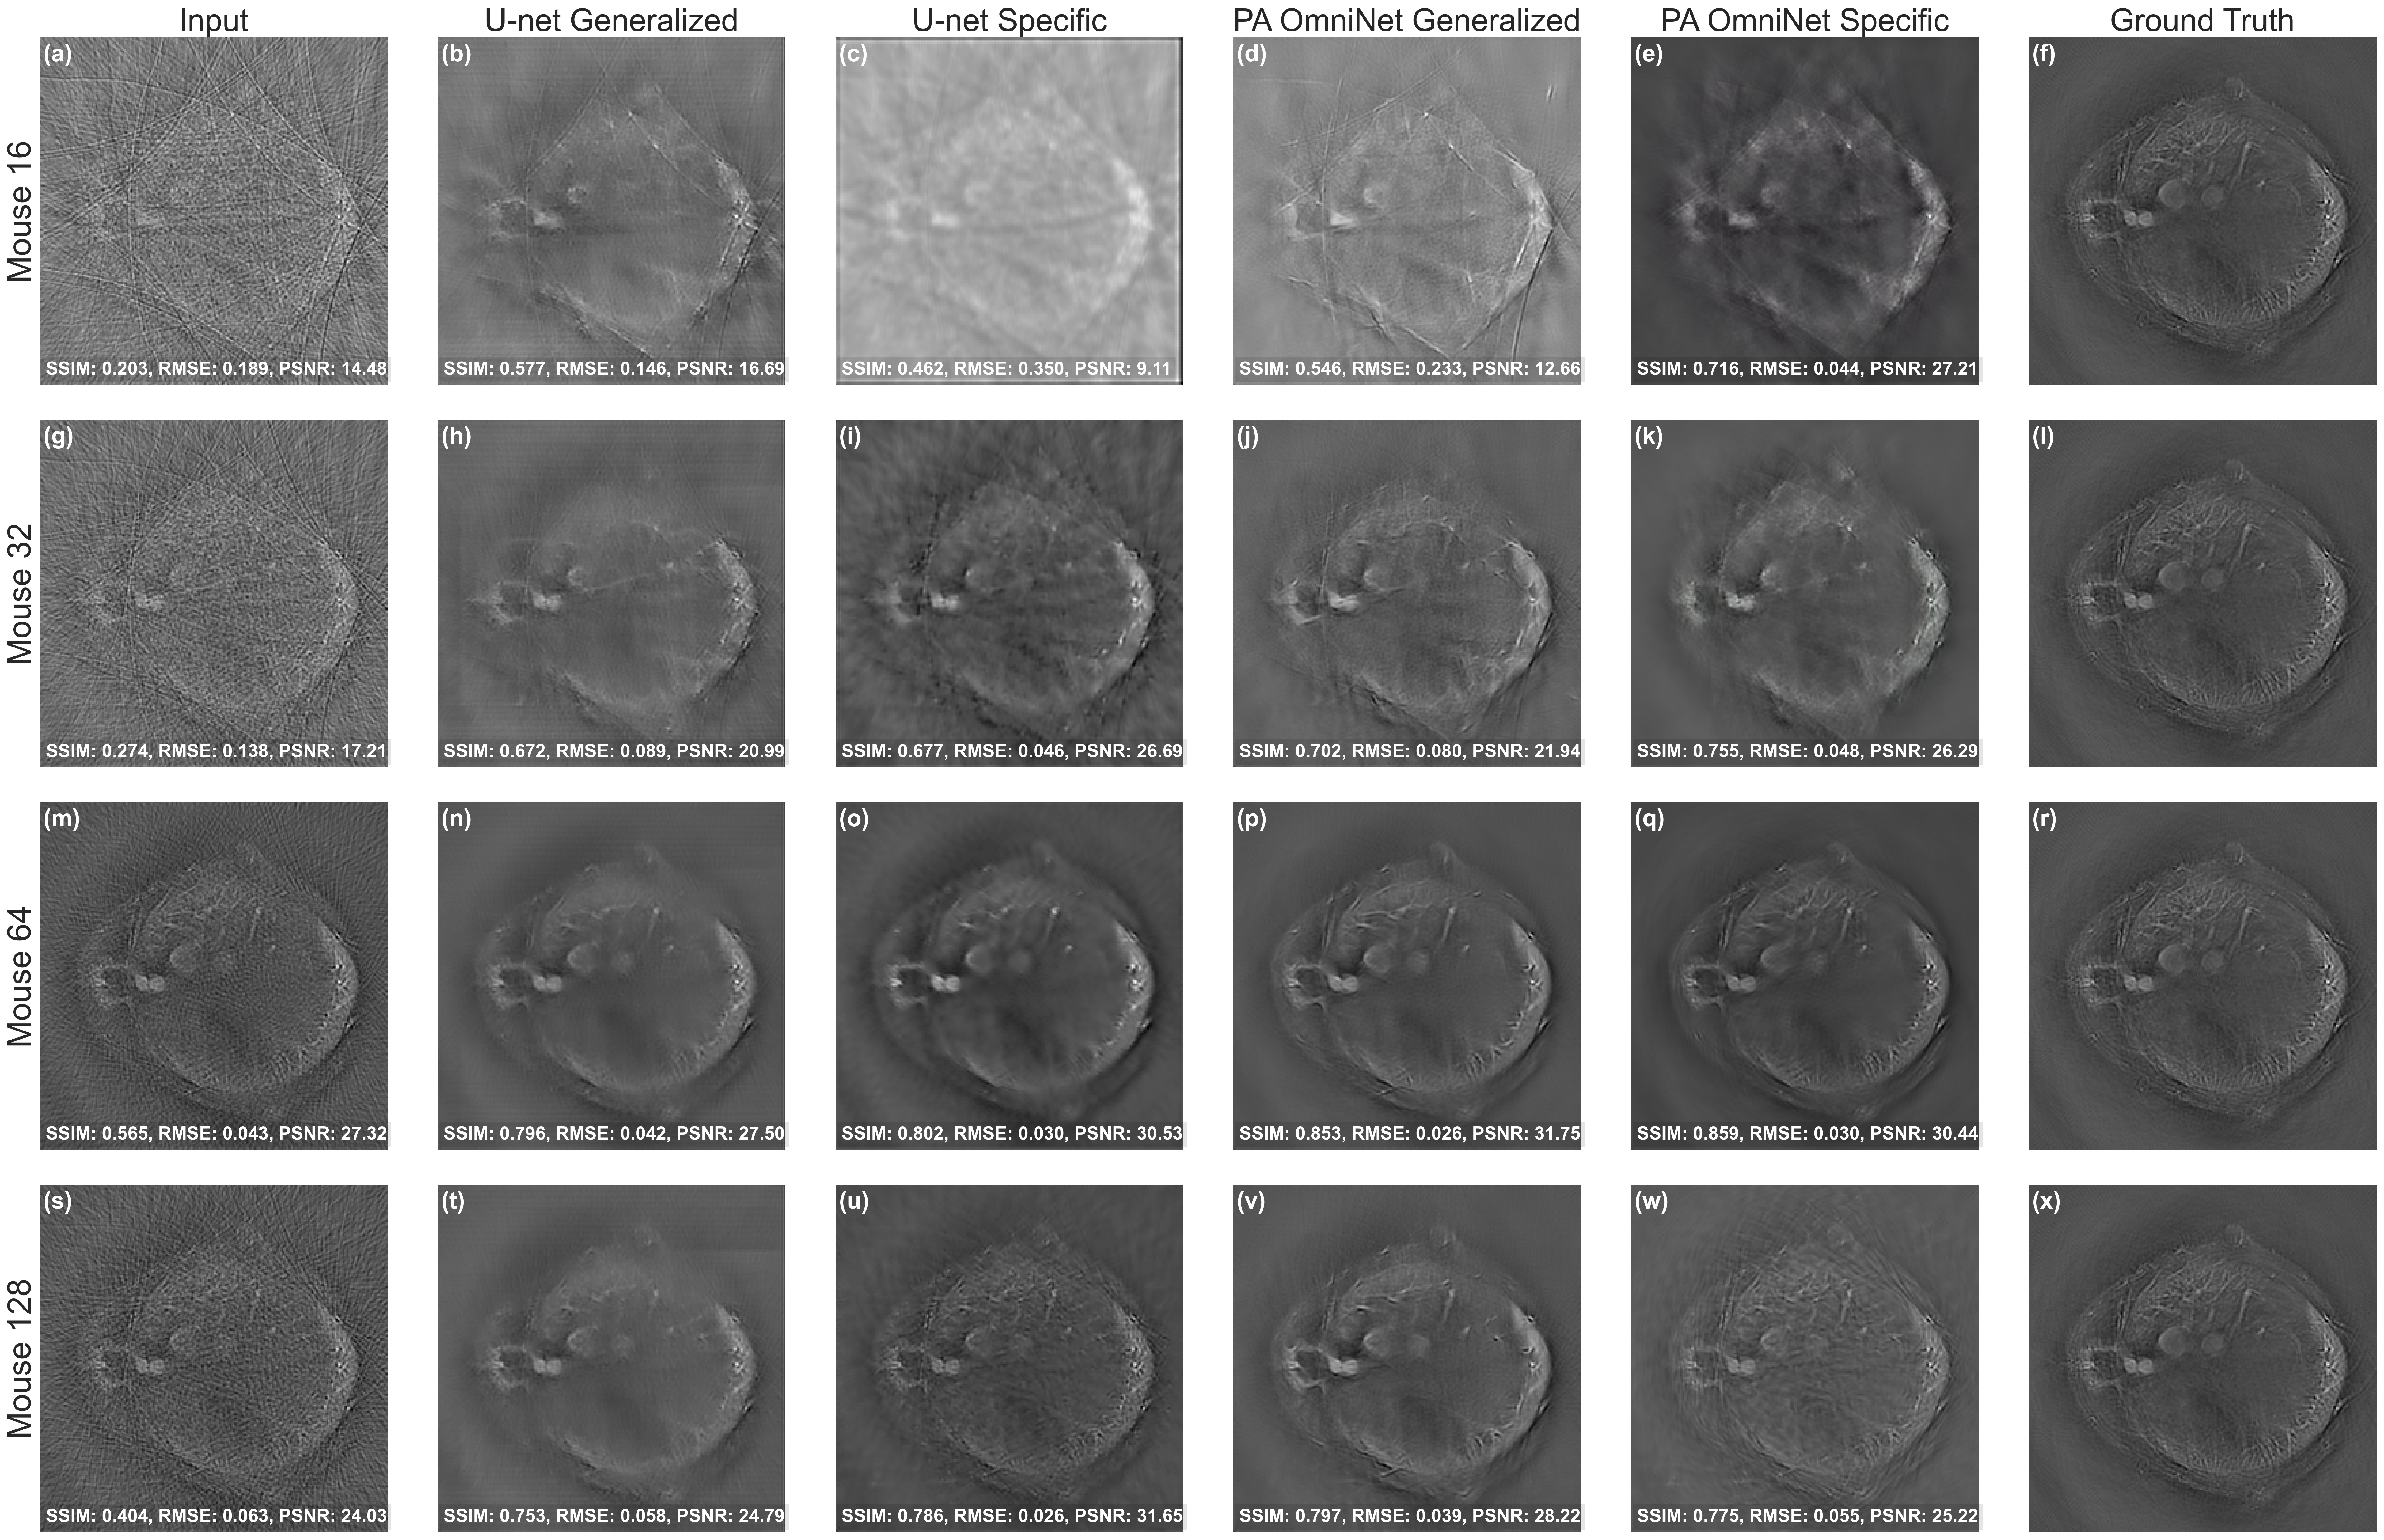

In [21]:
input_img_semi, Unet_generalized_img_semi, Unet_specific_img_semi, PA_generalized_img_semi, PA_specific_img_semi, output_img_semi, [baseline_metrics_semi, Unet_generalized_metrics_semi, Unet_specific_metrics_semi, PA_generalized_metrics_semi, PA_specific_metrics_semi] =(
    get_row(X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse16, Unet_mse_mouse16))

input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi, [baseline_metrics_multi, Unet_generalized_metrics_multi, Unet_specific_metrics_multi, PA_generalized_metrics_multi, PA_specific_metrics_multi] =(
    get_row(X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse32, Unet_mse_mouse32))

input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD, [baseline_metrics_MSFD, Unet_generalized_metrics_MSFD, Unet_specific_metrics_MSFD, PA_generalized_metrics_MSFD, PA_specific_metrics_MSFD] =(
    get_row(X_Neuralizer_MSFD, y_Neuralizer_MSFD, X_context_MSFD, y_context_MSFD, X_unet_MSFD, y_unet_MSFD, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse64, Unet_mse_mouse64))
input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD, [baseline_metrics_SCD, Unet_generalized_metrics_SCD, Unet_specific_metrics_SCD, PA_generalized_metrics_SCD, PA_specific_metrics_SCD] =(
    get_row(X_Neuralizer_SCD, y_Neuralizer_SCD, X_context_SCD, y_context_SCD, X_unet_SCD, y_unet_SCD, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse128, Unet_mse_mouse128))
titles = ['Input', 'U-net Generalized', 'U-net Specific', 'PA OmniNet Generalized', 'PA OmniNet Specific', 'Ground Truth']
images = [input_img_semi, Unet_generalized_img_semi, Unet_specific_img_semi, PA_generalized_img_semi, PA_specific_img_semi, output_img_semi,
          input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi,
          input_img_MSFD, Unet_generalized_img_MSFD, Unet_specific_img_MSFD, PA_generalized_img_MSFD, PA_specific_img_MSFD, output_img_MSFD,
          input_img_SCD, Unet_generalized_img_SCD, Unet_specific_img_SCD, PA_generalized_img_SCD, PA_specific_img_SCD, output_img_SCD]

plt.figure(figsize=(34, 18))

metrics = [
    f"SSIM: {baseline_metrics_semi[2]:.3f}, RMSE: {baseline_metrics_semi[0]:.3f}, PSNR: {baseline_metrics_semi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_semi[2]:.3f}, RMSE: {Unet_generalized_metrics_semi[0]:.3f}, PSNR: {Unet_generalized_metrics_semi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_semi[2]:.3f}, RMSE: {Unet_specific_metrics_semi[0]:.3f}, PSNR: {Unet_specific_metrics_semi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_semi[2]:.3f}, RMSE: {PA_generalized_metrics_semi[0]:.3f}, PSNR: {PA_generalized_metrics_semi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_semi[2]:.3f}, RMSE: {PA_specific_metrics_semi[0]:.3f}, PSNR: {PA_specific_metrics_semi[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_multi[2]:.3f}, RMSE: {baseline_metrics_multi[0]:.3f}, PSNR: {baseline_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_multi[2]:.3f}, RMSE: {Unet_generalized_metrics_multi[0]:.3f}, PSNR: {Unet_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_multi[2]:.3f}, RMSE: {Unet_specific_metrics_multi[0]:.3f}, PSNR: {Unet_specific_metrics_multi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_multi[2]:.3f}, RMSE: {PA_generalized_metrics_multi[0]:.3f}, PSNR: {PA_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_multi[2]:.3f}, RMSE: {PA_specific_metrics_multi[0]:.3f}, PSNR: {PA_specific_metrics_multi[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_MSFD[2]:.3f}, RMSE: {baseline_metrics_MSFD[0]:.3f}, PSNR: {baseline_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_MSFD[2]:.3f}, RMSE: {Unet_generalized_metrics_MSFD[0]:.3f}, PSNR: {Unet_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_MSFD[2]:.3f}, RMSE: {Unet_specific_metrics_MSFD[0]:.3f}, PSNR: {Unet_specific_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_MSFD[2]:.3f}, RMSE: {PA_generalized_metrics_MSFD[0]:.3f}, PSNR: {PA_generalized_metrics_MSFD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_MSFD[2]:.3f}, RMSE: {PA_specific_metrics_MSFD[0]:.3f}, PSNR: {PA_specific_metrics_MSFD[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_SCD[2]:.3f}, RMSE: {baseline_metrics_SCD[0]:.3f}, PSNR: {baseline_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_SCD[2]:.3f}, RMSE: {Unet_generalized_metrics_SCD[0]:.3f}, PSNR: {Unet_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_SCD[2]:.3f}, RMSE: {Unet_specific_metrics_SCD[0]:.3f}, PSNR: {Unet_specific_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_SCD[2]:.3f}, RMSE: {PA_generalized_metrics_SCD[0]:.3f}, PSNR: {PA_generalized_metrics_SCD[1]:.2f}",
    f"SSIM: {PA_specific_metrics_SCD[2]:.3f}, RMSE: {PA_specific_metrics_SCD[0]:.3f}, PSNR: {PA_specific_metrics_SCD[1]:.2f}",
    "Ground Truth",
]

plt.figure(figsize=(34, 24), dpi=250)

alphabet = string.ascii_lowercase[:len(images)]
for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
    ax = plt.subplot(4, 6, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.01, 0.95, f"({letter})", fontsize=22, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

    if idx % 6 == 0:

        row_label = ['Mouse 16', 'Mouse 32', 'Mouse 64', 'Mouse 128'][idx // 6]
        ax.text(-.05, 0.5, row_label, fontsize=30, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

    if idx < 6:
        plt.title(titles[idx], fontsize=29)

    if metric != "Ground Truth":
        ax.text(0.017, 0.02, metric, fontsize=17, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes,  fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.01, hspace=0.1)
plt.show()


In [26]:
X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi = get_all_test_data(v_phantom, [0,2], CONTEXT_SIZE=16)
X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi = get_all_test_data(v_phantom, [1,2], CONTEXT_SIZE=16)


In this order:
X_test_Neur = torch.Size([20, 3, 256, 256]), y_test_Neur = torch.Size([20, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 256, 256])
X_test_Unet = torch.Size([20, 256, 256]), y_test_Unet = torch.Size([20, 256, 256])
In this order:
X_test_Neur = torch.Size([20, 3, 256, 256]), y_test_Neur = torch.Size([20, 3, 256, 256]), X_context = torch.Size([16, 3, 256, 256]), y_context = torch.Size([16, 3, 256, 256])
X_test_Unet = torch.Size([20, 256, 256]), y_test_Unet = torch.Size([20, 256, 256])


In [27]:
input_img_semi, Unet_generalized_img_semi, Unet_specific_img_semi, PA_generalized_img_semi, PA_specific_img_semi, output_img_semi, [baseline_metrics_semi, Unet_generalized_metrics_semi, Unet_specific_metrics_semi, PA_generalized_metrics_semi, PA_specific_metrics_semi] =(
    get_row(X_Neuralizer_Semi, y_Neuralizer_Semi, X_context_Semi, y_context_Semi, X_unet_Semi, y_unet_Semi, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse16, Unet_mse_mouse16))

input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi, [baseline_metrics_multi, Unet_generalized_metrics_multi, Unet_specific_metrics_multi, PA_generalized_metrics_multi, PA_specific_metrics_multi] =(
    get_row(X_Neuralizer_Multi, y_Neuralizer_Multi, X_context_Multi, y_context_Multi, X_unet_Multi, y_unet_Multi, PAOmniNet_alpha_generalized, Unet_mse_generalized, PAOmniNet_alpha_mouse32, Unet_mse_mouse32))

titles = ['Input', 'U-net Generalized', 'U-net Specific', 'PA OmniNet Generalized', 'PA OmniNet Specific', 'Ground Truth']
images = [input_img_semi, Unet_generalized_img_semi, Unet_specific_img_semi, PA_generalized_img_semi, PA_specific_img_semi, output_img_semi,
          input_img_multi, Unet_generalized_img_multi, Unet_specific_img_multi, PA_generalized_img_multi, PA_specific_img_multi, output_img_multi]

plt.figure(figsize=(34, 18))

metrics = [
    f"SSIM: {baseline_metrics_semi[2]:.3f}, RMSE: {baseline_metrics_semi[0]:.3f}, PSNR: {baseline_metrics_semi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_semi[2]:.3f}, RMSE: {Unet_generalized_metrics_semi[0]:.3f}, PSNR: {Unet_generalized_metrics_semi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_semi[2]:.3f}, RMSE: {Unet_specific_metrics_semi[0]:.3f}, PSNR: {Unet_specific_metrics_semi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_semi[2]:.3f}, RMSE: {PA_generalized_metrics_semi[0]:.3f}, PSNR: {PA_generalized_metrics_semi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_semi[2]:.3f}, RMSE: {PA_specific_metrics_semi[0]:.3f}, PSNR: {PA_specific_metrics_semi[1]:.2f}",
    "Ground Truth",

    f"SSIM: {baseline_metrics_multi[2]:.3f}, RMSE: {baseline_metrics_multi[0]:.3f}, PSNR: {baseline_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_generalized_metrics_multi[2]:.3f}, RMSE: {Unet_generalized_metrics_multi[0]:.3f}, PSNR: {Unet_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {Unet_specific_metrics_multi[2]:.3f}, RMSE: {Unet_specific_metrics_multi[0]:.3f}, PSNR: {Unet_specific_metrics_multi[1]:.2f}",
    f"SSIM: {PA_generalized_metrics_multi[2]:.3f}, RMSE: {PA_generalized_metrics_multi[0]:.3f}, PSNR: {PA_generalized_metrics_multi[1]:.2f}",
    f"SSIM: {PA_specific_metrics_multi[2]:.3f}, RMSE: {PA_specific_metrics_multi[0]:.3f}, PSNR: {PA_specific_metrics_multi[1]:.2f}",
    "Ground Truth",

]

plt.figure(figsize=(34, 12), dpi=400)

alphabet = string.ascii_lowercase[:len(images)]
for idx, (img, metric, letter) in enumerate(zip(images, metrics, alphabet)):
    ax = plt.subplot(2, 6, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    ax.text(0.01, 0.95, f"({letter})", fontsize=22, va='center', ha='left', color='white', fontweight='bold', transform=ax.transAxes)

    if idx % 6 == 0:
        # row_label = ['SWFD Multi', 'MSFD', 'SCD'][idx // 6]
        row_label = ['Vphantom 16', 'Vphantom 32', 'Mouse 64', 'Mouse 128'][idx // 6]
        ax.text(-.05, 0.5, row_label, fontsize=30, va='center', ha='center', rotation='vertical', transform=ax.transAxes)

    if idx < 6:
        plt.title(titles[idx], fontsize=29)

    if metric != "Ground Truth":
        ax.text(0.017, 0.02, metric, fontsize=17, color="white",
                bbox=dict(facecolor='black', alpha=0.1, edgecolor='none'),
                va="bottom", ha="left", transform=ax.transAxes,  fontweight='bold')

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1, wspace=0.01, hspace=0.1)
plt.show()


<Figure size 3400x1800 with 0 Axes>